In [1]:
#pip install praw
## This method requires client_id and client_secret associated to a Reddit account,
## and https://www.reddit.com/r/redditdev/comments/1s0j1sq/retrieve_client_id_secret/
## says that Reddit is likely to reject your request for applying one.

## Backup source: ASU library https://dataverse.asu.edu/dataset.xhtml?persistentId=doi%3A10.48349%2FASU%2FWLV8JA&utm_source=chatgpt.com

This note book is to explore what kind of raw data can we get from Reddit comments, and inspect its content to select useful information.

In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt

## Current method: Extract Reddit comments using Arctic Shift API:
https://github.com/ArthurHeitmann/arctic_shift

limitations: 100 comments per inquiry

| Status Code | Meaning | Description |
|---|---|---|
| `200` | Success | Request accepted |
| `400` | Bad Request | Invalid or malformed request |
| `422` | Unprocessable Content | Request structure is valid, but parameter values aren’t acceptable |
| `429` | Too Many Requests | Rate limiting |
| `500` | Server Error | Problem on the server |
| `522` | Server Error | Cloudflare connection problem |


Obseravtions:
- Interestingly, searching between a longer period (a few weeks) is more likely to return `200`, compared to searching for a short period (a few days)
- It search comemnts from the lastest date first

In [1]:
url = "https://arctic-shift.photon-reddit.com/api/comments/search"

params = {
    "subreddit": "wallstreetbets",
    "body": "GME",
    "after": "2021-01-01",
    "before": "2021-02-01",
    "limit": 100
}

r = requests.get(url, params=params)


print("Request status (accepted: 200; rejected: 400):", r.status_code)
print("Type:",r.headers.get("Content-Type"))
print("Suggested reset wait time:",  r.headers.get("X-RateLimit-Reset"))
print(r.text[:500])

data = r.json()


NameError: name 'requests' is not defined

### Whats inside `data`?

#### Inspect the raw data (doing nothing here yet)

In [ ]:
# JSON structures
print("Type:", type(data))
print("Top-level keys:", data.keys())

Type: <class 'dict'>
Top-level keys: dict_keys(['data'])


In [ ]:
print("Content Type:", type(data["data"]))
print("Length:",len(data["data"]))

Content Type: <class 'list'>
Length: 50


In [ ]:
# Dump first few lines
## key/field name --- "associated_award"
## value --- null
## key-value pair --- "associated_award": null,

print(json.dumps(data, indent=2)[:200])

{
  "data": [
    {
      "all_awardings": [],
      "associated_award": null,
      "author": "Rshiryakin_instagram",
      "author_created_utc": null,
      "author_flair_background_color": null,
  


In [ ]:
# An example comment:
print(data["data"][5]["body"])

I do see all the inflation being hidden in the Market. But this is a bubble and people are maxing  out their credit cards, and cleaning out their bank accounts for this.

I'm going to be honest, if I got into this 1-3 months ago I would be selling every last share.     I could pay off my mortgage do a few renovations around my place, buy some silver and give my parents a few thousand bucks.     

If you're new to stocks, please do research!   START OUT WITH INDEX FUNDS and SELL whatever  GME,BB, and AMC stock after you made a few bucks


In [ ]:
print(json.dumps(data["data"][0], indent=2))

{
  "all_awardings": [],
  "associated_award": null,
  "author": "Rshiryakin_instagram",
  "author_created_utc": null,
  "author_flair_background_color": null,
  "author_flair_css_class": null,
  "author_flair_richtext": [],
  "author_flair_template_id": null,
  "author_flair_text": null,
  "author_flair_text_color": null,
  "author_flair_type": "text",
  "author_fullname": "t2_a0dacjg4",
  "author_patreon_flair": false,
  "author_premium": false,
  "awarders": [],
  "body": "NOK\ud83d\ude80\ud83d\ude80\ud83d\ude80\ud83c\uddf7\ud83c\uddfa\ud83c\uddf7\ud83c\uddfa\ud83c\uddf7\ud83c\uddfaAll Russia Buy #NOK. We can\u2019t buy amc and gme\ud83c\uddf7\ud83c\uddfa\ud83c\uddf7\ud83c\uddfa\ud83c\uddf7\ud83c\uddfa",
  "can_gild": true,
  "can_mod_post": false,
  "collapsed": false,
  "collapsed_because_crowd_control": null,
  "collapsed_reason": null,
  "comment_type": null,
  "controversiality": 0,
  "created_utc": 1612137597,
  "distinguished": null,
  "edited": false,
  "gilded": 0,
  "gildi

#### Clean up fields and describe what is left

Can turn this cleaning part as a function.

In [ ]:
# Clean up step-by-step: comments--> comments_clean1 --> comments_clean2 .
comments=data["data"]

In [ ]:
## Clean up NOT useful fields
DROP_COLUMNS = [
    # Awards
    "all_awardings",
    "associated_award",
    "awarders",
    "gilded",
    "gildings",
    "top_awarded_type",
    "total_awards_received",

    # Author flair / UI information
    "author_flair_background_color",
    "author_flair_css_class",
    "author_flair_richtext",
    "author_flair_template_id",
    "author_flair_text",
    "author_flair_text_color",
    "author_flair_type",
    "author_patreon_flair",
    "author_premium",

    # Reddit UI / permissions
    "can_gild",
    "can_mod_post",
    "collapsed",
    "collapsed_because_crowd_control",
    "collapsed_reason",
    "locked",
    "no_follow",
    "send_replies",

    # Moderation / system metadata
    "comment_type",
    "quarantined",
    "removal_reason",
    "treatment_tags",

    # User Profile information
    "author_created_utc",
    "author_fullname",

    # Irrelevant
    "retrieved_on",
    "permalink",
    "edited" #why care if the comment is edited or not?
]

comments_clean1 = []

for comment in comments:
    cleaned = {
        key: value
        for key, value in comment.items()
        if key not in DROP_COLUMNS
    }

    comments_clean1.append(cleaned)

## What is left after the 1st cleaning
comments_clean1[0:2]

[{'author': 'Rshiryakin_instagram',
  'body': 'NOK🚀🚀🚀🇷🇺🇷🇺🇷🇺All Russia Buy #NOK. We can’t buy amc and gme🇷🇺🇷🇺🇷🇺',
  'controversiality': 0,
  'created_utc': 1612137597,
  'distinguished': None,
  'id': 'gljciac',
  'is_submitter': False,
  'link_id': 't3_l9kn3z',
  'parent_id': 't3_l9kn3z',
  'score': 1,
  'stickied': False,
  'subreddit': 'wallstreetbets',
  'subreddit_id': 't5_2th52',
  'subreddit_name_prefixed': 'r/wallstreetbets',
  'subreddit_type': 'public',
  'name': 't1_gljciac',
  'ups': 1},
 {'author': 'Focus323',
  'body': 'they are not legally obligated to. They have loopholes\n\n \n\n**Be careful, there are a lot of ETFs out there that claim that they are backed by Silver and Gold, but in the fine print, indicate that they would not have to deliver if they are called out on it.**\n\n**ETF plays, are** ***PSLV*** **for silver, as they are backed by actual silver. DO NOT buy SLV, as that etf will not deliver on physical silver.**\n\nI am buying, **physical silver, gold, and th

In [ ]:
## Clean up duplicates
DROP_REDUNDANT = [
# name --> fullname for the comment
# t1_  → comment
# t3_  → submission/post
# t5_  → subreddit
    "name",
    "subreddit_name_prefixed", #subreddit wiht r/ in front
    "subreddit_id", #unique Reddit ID for the subreddit
    "subreddit_type" # Everything we got should already public.
]

comments_clean2 = []

for comment in comments_clean1:
    cleaned = {
        key: value
        for key, value in comment.items()
        if key not in DROP_REDUNDANT
    }

    comments_clean2.append(cleaned)

## What is left after the 1st cleaning
comments_clean2[0:2]

[{'author': 'Rshiryakin_instagram',
  'body': 'NOK🚀🚀🚀🇷🇺🇷🇺🇷🇺All Russia Buy #NOK. We can’t buy amc and gme🇷🇺🇷🇺🇷🇺',
  'controversiality': 0,
  'created_utc': 1612137597,
  'distinguished': None,
  'id': 'gljciac',
  'is_submitter': False,
  'link_id': 't3_l9kn3z',
  'parent_id': 't3_l9kn3z',
  'score': 1,
  'stickied': False,
  'subreddit': 'wallstreetbets',
  'ups': 1},
 {'author': 'Focus323',
  'body': 'they are not legally obligated to. They have loopholes\n\n \n\n**Be careful, there are a lot of ETFs out there that claim that they are backed by Silver and Gold, but in the fine print, indicate that they would not have to deliver if they are called out on it.**\n\n**ETF plays, are** ***PSLV*** **for silver, as they are backed by actual silver. DO NOT buy SLV, as that etf will not deliver on physical silver.**\n\nI am buying, **physical silver, gold, and the miners.** Physical Silver is my preferred investment. How high can the price go? Not sure, but we can be certain that owning physic

The fields left now are:

| Field | Description |
|---|---|
| `author` | Reddit username of the commenter. |
| `body` | The actual text content of the comment. |
| `controversiality` | Reddit indicator showing whether the comment received controversial votes. |
| `created_utc` | Unix timestamp indicating when the comment was created. |
| `distinguished` | Indicates whether the comment was given a special moderator/admin designation. |
| `id` | Unique identifier for the comment. |
| `is_submitter` | Indicates whether the commenter is the author of the submission. |
| `link_id` | Unique identifier of the submission containing the comment. |
| `parent_id` | Identifier of the comment or submission that this comment directly replies to. |
| `score` | Net Reddit vote score representing the comment's engagement. |
| `stickied` | Indicates whether the comment was pinned by a moderator. |
| `subreddit` | Name of the subreddit where the comment was posted. |
| `ups` | Number of upvotes received by the comment; largely redundant with `score` for this analysis. |

### Explore distributions

Start with `comments_clean2` as a clean dictionary, and build a dataframe

In [ ]:
df = pd.DataFrame(comments_clean2)
df[0:4]

,author,body,controversiality,created_utc,distinguished,id,is_submitter,link_id,parent_id,score,stickied,subreddit,ups
0,Rshiryakin_instagram,NOK🚀🚀🚀🇷🇺🇷🇺🇷🇺All Russia Buy #NOK. We can’t buy ...,0,1612137597,None,gljciac,False,t3_l9kn3z,t3_l9kn3z,1,False,wallstreetbets,1
1,Focus323,they are not legally obligated to. They have l...,0,1612137596,None,gljci6g,False,t3_l9gv98,t1_gljbxmd,2,False,wallstreetbets,2
2,CockInAClock,GME GME GME!!! WHOOOOOO!!!!!,0,1612137595,None,gljci3z,False,t3_l9lvrn,t3_l9lvrn,17,False,wallstreetbets,17
3,Vanhelgan,Newly realised smooth brain apetard reporting!...,0,1612137595,None,gljci4q,False,t3_l9n5sz,t3_l9n5sz,1,False,wallstreetbets,1


In [ ]:
## Select authors that post more than 1 comment
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   author            50 non-null     object
 1   body              50 non-null     object
 2   controversiality  50 non-null     int64 
 3   created_utc       50 non-null     int64 
 4   distinguished     0 non-null      object
 5   id                50 non-null     object
 6   is_submitter      50 non-null     bool  
 7   link_id           50 non-null     object
 8   parent_id         50 non-null     object
 9   score             50 non-null     int64 
 10  stickied          50 non-null     bool  
 11  subreddit         50 non-null     object
 12  ups               50 non-null     int64 
dtypes: bool(2), int64(4), object(7)
memory usage: 4.5+ KB


In [ ]:
### Group columns by Dtype:
df_object = df.select_dtypes(include=["object"]).drop(columns=["body"]) # "body" column needs special treatments
df_int = df.select_dtypes(include=["int64"])
df_bool = df.select_dtypes(include=["bool"])
print(df_object.columns.tolist())
print(df_int.columns.tolist())
print(df_bool.columns.tolist())

['author', 'distinguished', 'id', 'link_id', 'parent_id', 'subreddit']
['controversiality', 'created_utc', 'score', 'ups']
['is_submitter', 'stickied']


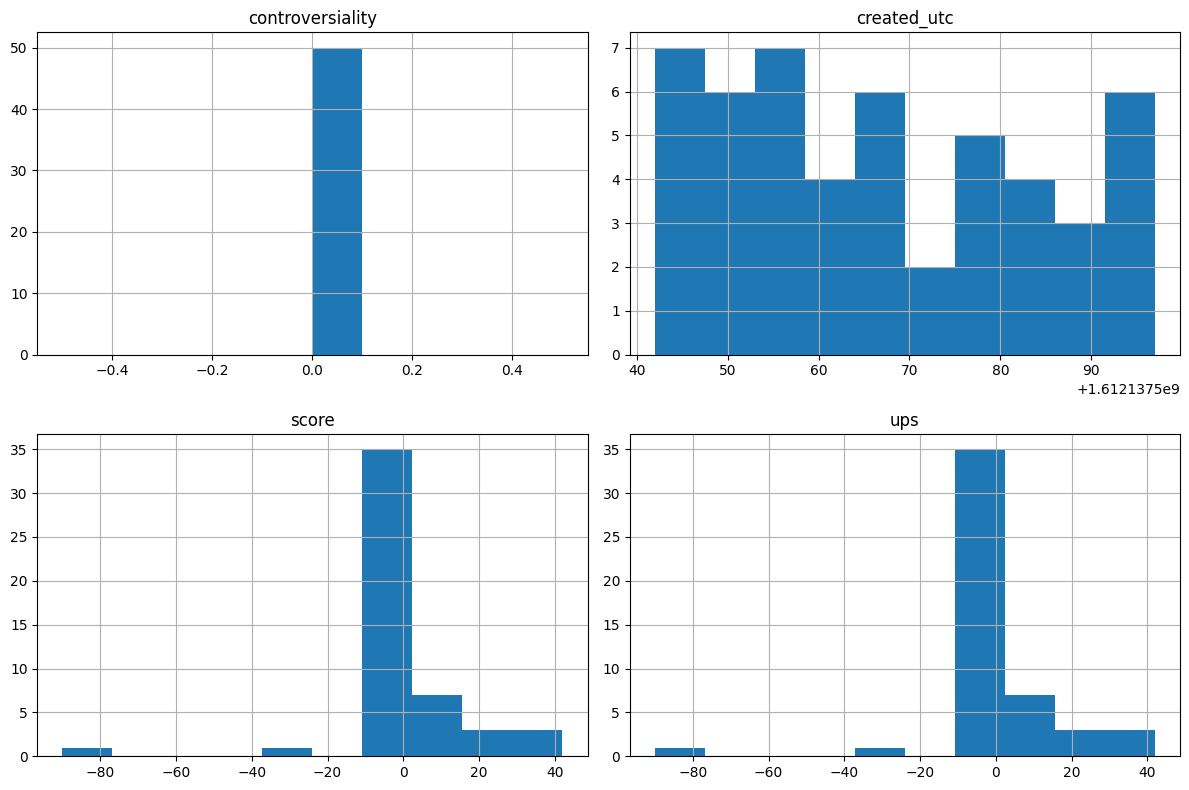

In [ ]:
df_int.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

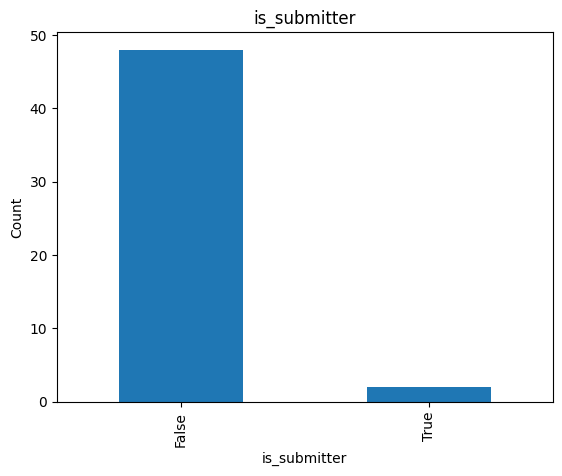

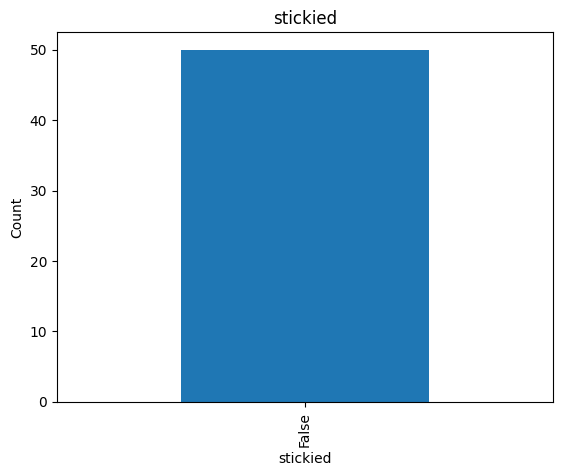

In [ ]:
for col in df_bool.columns:
    df_bool[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

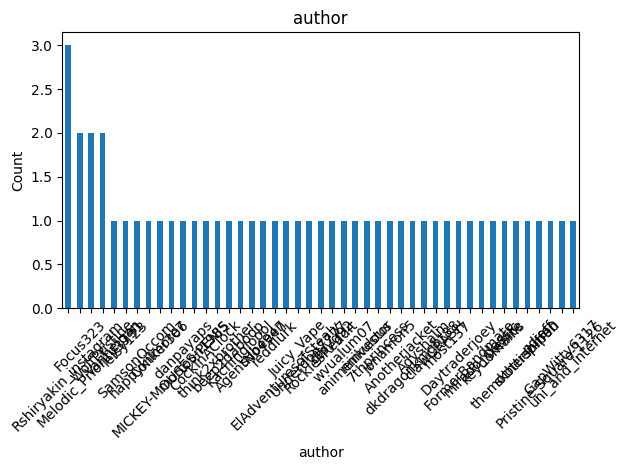

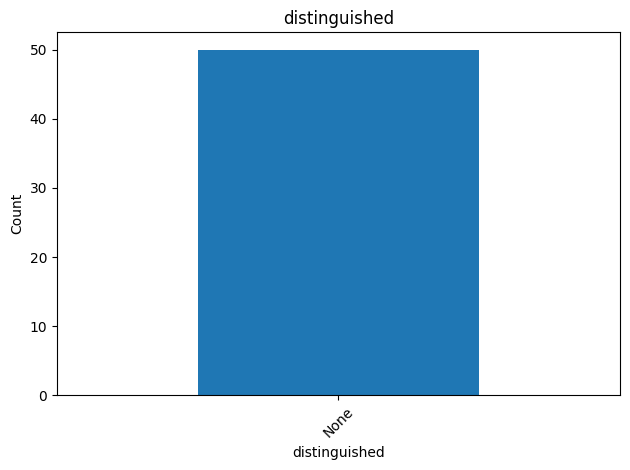

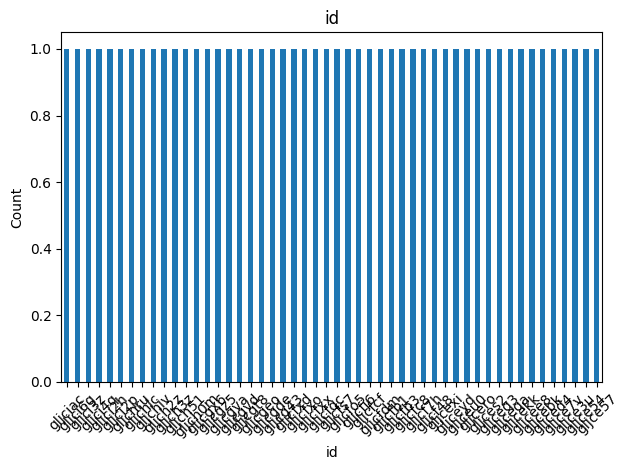

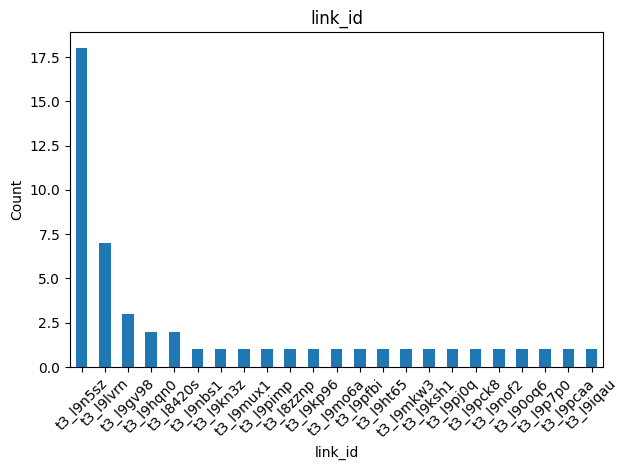

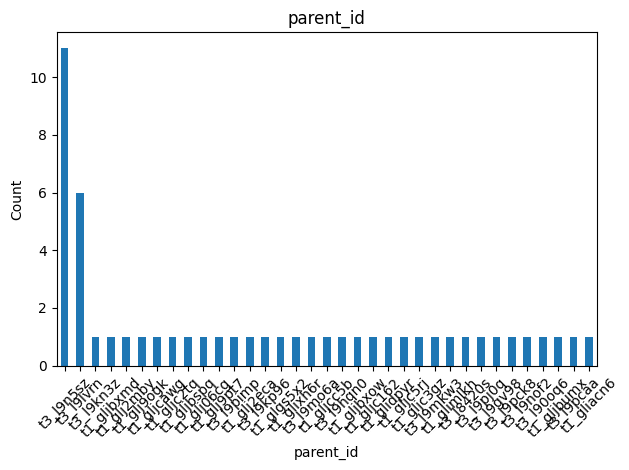

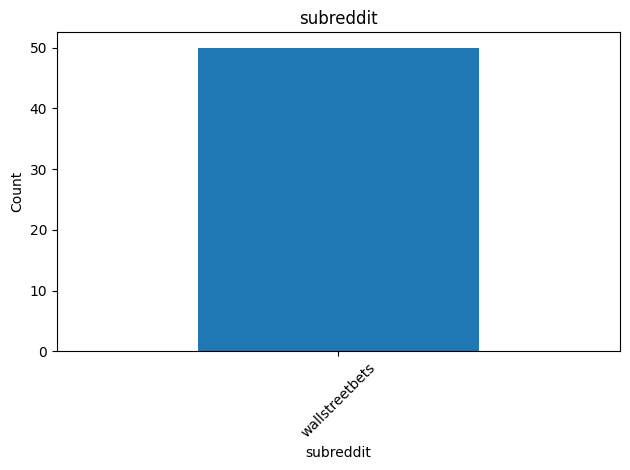

In [ ]:
for col in df_object.columns:
    df_object[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
## Body needs special treatment:
df["body"][0:3]

,body
0,NOK🚀🚀🚀🇷🇺🇷🇺🇷🇺All Russia Buy #NOK. We can’t buy ...
1,they are not legally obligated to. They have l...
2,GME GME GME!!! WHOOOOOO!!!!!


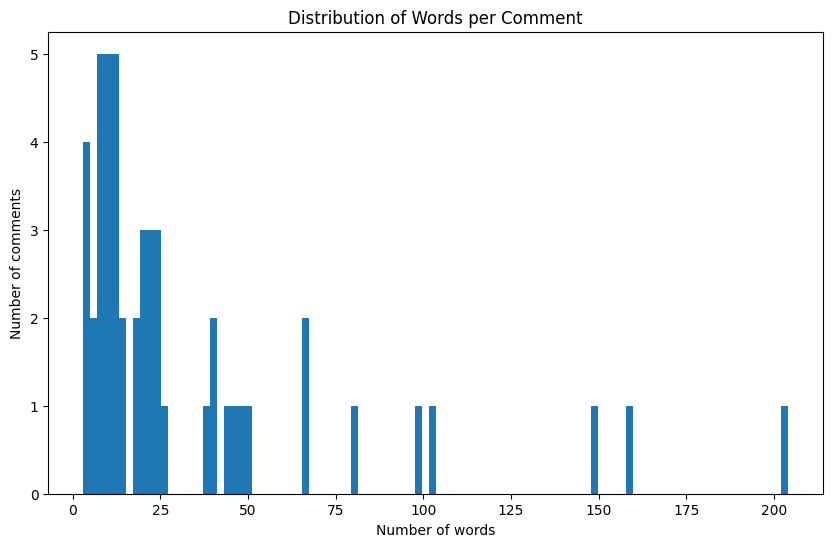

count     50.000000
mean      34.240000
std       42.315414
min        3.000000
25%       10.000000
50%       19.500000
75%       40.750000
max      204.000000
Name: body, dtype: float64


In [ ]:
# Count words in each comment
word_counts = df["body"].fillna("").str.split().str.len()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=100)
plt.xlabel("Number of words")
plt.ylabel("Number of comments")
plt.title("Distribution of Words per Comment")
plt.show()
print(word_counts.describe())

#### author

In [ ]:
## Check author
df["author"].value_counts()[lambda x: x > 1]

,count
author,
Rshiryakin_instagram,3
Focus323,2
Melodic_Priority3791,2
WolfPristine,2


In [ ]:
### What did these author say?
df[df["author"] == "Focus323"]

,author,body,controversiality,created_utc,distinguished,id,is_submitter,link_id,parent_id,score,stickied,subreddit,ups,datetime
1,Focus323,they are not legally obligated to. They have l...,0,1612137596,None,gljci6g,False,t3_l9gv98,t1_gljbxmd,2,False,wallstreetbets,2,2021-01-31 23:59:56+00:00
27,Focus323,"\n\n**Be careful, there are a lot of ETFs out...",0,1612137561,None,gljcfj6,False,t3_l9gv98,t1_gljc162,1,False,wallstreetbets,1,2021-01-31 23:59:21+00:00


## Save a copy to google drive

In [ ]:
import os
from google.colab import drive

In [ ]:
drive.mount(f"/content/drive/")
print(os.getcwd())

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content


In [ ]:
project_path = "/content/drive/MyDrive/Colab Notebooks/dl-quant_project/Trash"
df.to_parquet(
    f"{project_path}/wallstreetbets_GME_comments.parquet",
    index=False
)
#print(os.path.exists("wallstreetbets_comments.parquet"))

## csv is preferred at small scale.
df.to_csv(
    f"{project_path}/wallstreetbets_GME_comments.csv",
    index=False
)

## Others